<a href="https://colab.research.google.com/github/FatherNurt/FUNt-Cosmologiical-Model-of-All-Things/blob/main/01_FUNt_Core_Transition_Engine_v1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FUNt Core Transition Engine v1.0
## Frozen Domain-Neutral Transition Grammar

Generated as part of the FUNt Transition Laboratory notebook suite.

## Purpose

This notebook is the frozen core transition engine.

It models the general transition grammar:

```text
Reference → Potential Difference → Transport → Persistence → Allowance → Transition → Relaxation → Reference
```

It does not fetch space-weather data, compute geometry, or perform prediction-specific tuning. It is intended to be domain-neutral.

In [1]:
import json
import math
import hashlib
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

UTC_NOW = datetime.now(timezone.utc)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

VERSION = "FUNt Core Transition Engine v1.0"

CONFIG = {
    "version": VERSION,
    "transport_threshold": 0.30,
    "persistence_gain": 0.42,
    "relaxation_rate": 0.18,
    "survival_windows_x": 3,
    "tau_HRT": 3,
    "h3pi": 3.0 * math.pi,
    "psi_floor": 1.4656,
}

def config_hash(cfg):
    return hashlib.sha256(json.dumps(cfg, sort_keys=True, default=str).encode()).hexdigest()[:16]

CONFIG["config_hash"] = config_hash(CONFIG)
print(VERSION)
print("Config hash:", CONFIG["config_hash"])


FUNt Core Transition Engine v1.0
Config hash: ddc38c49d5385829


In [2]:
def consecutive_true_count(s: pd.Series) -> pd.Series:
    b = s.fillna(False).astype(bool)
    return b.astype(int).groupby((~b).cumsum()).cumsum()

def compute_core_transition_ledger(df, cfg=CONFIG):
    """
    Required input columns:
    - perturbation_index: normalized 0..1
    Optional:
    - geometry_gate_open: bool
    """
    out = df.copy()
    out["transport_T"] = np.sqrt(out["perturbation_index"].clip(0, 1))

    psi_vals, tau_vals = [], []
    psi, tau = 0.0, 0
    for T in out["transport_T"].fillna(0).values:
        gain = cfg["persistence_gain"] * max(0.0, T - cfg["transport_threshold"])
        leak = cfg["relaxation_rate"] * psi
        psi = max(0.0, psi + gain - leak)
        tau = tau + 1 if T > cfg["transport_threshold"] else 0
        psi_vals.append(psi)
        tau_vals.append(tau)

    out["Psi_persistence"] = psi_vals
    out["tau_persistent_windows"] = tau_vals

    psi_fraction = out["Psi_persistence"] / (cfg["psi_floor"] + out["Psi_persistence"])
    out["condition_T_gt_absPsi"] = out["transport_T"] > psi_fraction
    out["condition_tau_ge_HRT"] = out["tau_persistent_windows"] >= cfg["tau_HRT"]

    pressure_fraction = (0.65 * out["transport_T"] + 0.35 * psi_fraction).clip(0, 1.5)
    out["E_transition_pressure"] = cfg["h3pi"] * pressure_fraction
    out["condition_E_ge_h3pi"] = out["E_transition_pressure"] >= cfg["h3pi"]

    out["h3pi_candidate"] = (
        out["condition_T_gt_absPsi"] &
        out["condition_E_ge_h3pi"] &
        out["condition_tau_ge_HRT"]
    )

    out["candidate_survival_count"] = consecutive_true_count(out["h3pi_candidate"])
    out["condition_survives_x"] = out["candidate_survival_count"] >= cfg["survival_windows_x"]

    if "geometry_gate_open" not in out.columns:
        out["geometry_gate_open"] = True

    out["hHRT_allowance"] = out["condition_survives_x"] & out["geometry_gate_open"]
    out["transition_confirmed"] = out["h3pi_candidate"] & out["hHRT_allowance"]

    out["state"] = np.select(
        [
            out["transition_confirmed"],
            out["h3pi_candidate"] & ~out["condition_survives_x"],
            out["transport_T"] > cfg["transport_threshold"],
        ],
        ["transition_confirmed", "candidate_failed_persistence", "transport_perturbed"],
        default="reference_relaxation"
    )
    return out


,perturbation_index,transport_T,Psi_persistence,tau_persistent_windows,condition_T_gt_absPsi,condition_tau_ge_HRT,E_transition_pressure,condition_E_ge_h3pi,h3pi_candidate,candidate_survival_count,condition_survives_x,geometry_gate_open,hHRT_allowance,transition_confirmed,state
2026-06-17 16:42:03.342796+00:00,0.08,0.282843,0.000189,0,True,False,1.733149,False,False,0,False,True,False,False,reference_relaxation
2026-06-17 16:47:03.342796+00:00,0.08,0.282843,0.000155,0,True,False,1.733073,False,False,0,False,True,False,False,reference_relaxation
2026-06-17 16:52:03.342796+00:00,0.08,0.282843,0.000127,0,True,False,1.733010,False,False,0,False,True,False,False,reference_relaxation
2026-06-17 16:57:03.342796+00:00,0.08,0.282843,0.000104,0,True,False,1.732959,False,False,0,False,True,False,False,reference_relaxation
2026-06-17 17:02:03.342796+00:00,0.08,0.282843,0.000085,0,True,False,1.732916,False,False,0,False,True,False,False,reference_relaxation
2026-06-17 17:07:03.342796+00:00,0.08,0.282843,0.000070,0,True,False,1.732882,False,False,0,False,True,False,False,reference_relaxation
2026-06-17 17:12:03.342796+00:00,0.08,0.282843,0.000057,0,True,False,1.732854,False,False,0,False,True,False,False,reference_relaxation
2026-06-17 17:17:03.342796+00:00,0.08,0.282843,0.000047,0,True,False,1.732830,False,False,0,False,True,False,False,reference_relaxation
2026-06-17 17:22:03.342796+00:00,0.08,0.282843,0.000039,0,True,False,1.732811,False,False,0,False,True,False,False,reference_relaxation
2026-06-17 17:27:03.342796+00:00,0.08,0.282843,0.000032,0,True,False,1.732796,False,False,0,False,True,False,False,reference_relaxation


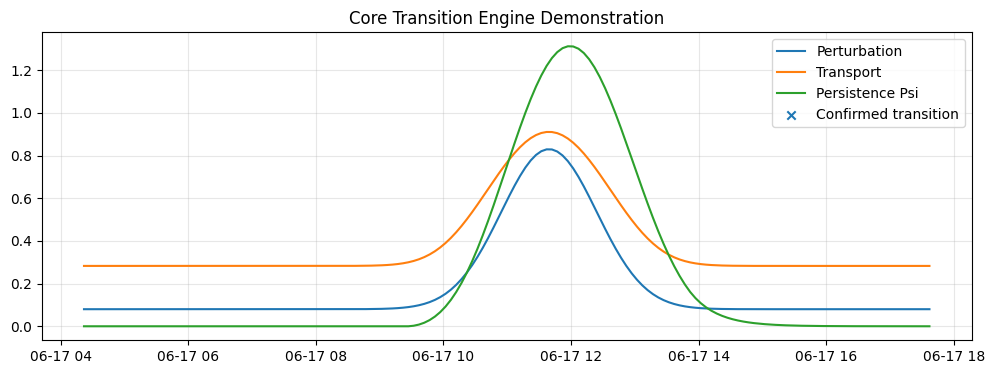

In [3]:
# Demonstration input only
idx = pd.date_range(end=UTC_NOW, periods=160, freq="5min")
x = np.linspace(0, 1, len(idx))
demo = pd.DataFrame(index=idx)
demo["perturbation_index"] = 0.08 + 0.75*np.exp(-((x-0.55)/0.08)**2)

ledger = compute_core_transition_ledger(demo)
display(ledger.tail(12))

plt.figure(figsize=(12,4))
plt.plot(ledger.index, ledger["perturbation_index"], label="Perturbation")
plt.plot(ledger.index, ledger["transport_T"], label="Transport")
plt.plot(ledger.index, ledger["Psi_persistence"], label="Persistence Psi")
plt.scatter(ledger.index[ledger["transition_confirmed"]], ledger.loc[ledger["transition_confirmed"], "transport_T"], marker="x", label="Confirmed transition")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Core Transition Engine Demonstration")
plt.show()
